<h1 style="text-align:center;">Framingham Heart Study</h1>

<h3>Preprocessing</h3>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.utils import resample

In [2]:
df=pd.read_csv("framingham .csv")

<h3>About DataSet</h3>

In [3]:
df.head(5)

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [4]:
df.tail(5)

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
4235,0,48,2.0,1,20.0,NaN,0,0,0,248.0,131.0,72.0,22.00,84.0,86.0,0
4236,0,44,1.0,1,15.0,0.0,0,0,0,210.0,126.5,87.0,19.16,86.0,NaN,0
4237,0,52,2.0,0,0.0,0.0,0,0,0,269.0,133.5,83.0,21.47,80.0,107.0,0
4238,1,40,3.0,0,0.0,0.0,0,1,0,185.0,141.0,98.0,25.60,67.0,72.0,0
4239,0,39,3.0,1,30.0,0.0,0,0,0,196.0,133.0,86.0,20.91,85.0,80.0,0


Size of DataSet

In [5]:
df.shape

(4240, 16)

Statistical Analysis


In [6]:
df.describe()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
count,4240.000000,4240.000000,4135.000000,4240.000000,4211.000000,4187.000000,4240.000000,4240.000000,4240.000000,4190.000000,4240.000000,4240.000000,4221.000000,4239.000000,3852.000000,4240.000000
mean,0.429245,49.580189,1.979444,0.494104,9.005937,0.029615,0.005896,0.310613,0.025708,236.699523,132.354599,82.897759,25.800801,75.878981,81.963655,0.151887
std,0.495027,8.572942,1.019791,0.500024,11.922462,0.169544,0.076569,0.462799,0.158280,44.591284,22.033300,11.910394,4.079840,12.025348,23.954335,0.358953
min,0.000000,32.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,107.000000,83.500000,48.000000,15.540000,44.000000,40.000000,0.000000
25%,0.000000,42.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,206.000000,117.000000,75.000000,23.070000,68.000000,71.000000,0.000000
50%,0.000000,49.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,234.000000,128.000000,82.000000,25.400000,75.000000,78.000000,0.000000
75%,1.000000,56.000000,3.000000,1.000000,20.000000,0.000000,0.000000,1.000000,0.000000,263.000000,144.000000,90.000000,28.040000,83.000000,87.000000,0.000000
max,1.000000,70.000000,4.000000,1.000000,70.000000,1.000000,1.000000,1.000000,1.000000,696.000000,295.000000,142.500000,56.800000,143.000000,394.000000,1.000000


Information about DS

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4240 entries, 0 to 4239
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4240 non-null   int64  
 1   age              4240 non-null   int64  
 2   education        4135 non-null   float64
 3   currentSmoker    4240 non-null   int64  
 4   cigsPerDay       4211 non-null   float64
 5   BPMeds           4187 non-null   float64
 6   prevalentStroke  4240 non-null   int64  
 7   prevalentHyp     4240 non-null   int64  
 8   diabetes         4240 non-null   int64  
 9   totChol          4190 non-null   float64
 10  sysBP            4240 non-null   float64
 11  diaBP            4240 non-null   float64
 12  BMI              4221 non-null   float64
 13  heartRate        4239 non-null   float64
 14  glucose          3852 non-null   float64
 15  TenYearCHD       4240 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 530.1 KB


Columns

In [8]:
df.columns

Index(['male', 'age', 'education', 'currentSmoker', 'cigsPerDay', 'BPMeds',
       'prevalentStroke', 'prevalentHyp', 'diabetes', 'totChol', 'sysBP',
       'diaBP', 'BMI', 'heartRate', 'glucose', 'TenYearCHD'],
      dtype='object')

<h3>Checking Missing Values</h3>

In [9]:
df.isnull().sum()

male                 0
age                  0
education          105
currentSmoker        0
cigsPerDay          29
BPMeds              53
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
TenYearCHD           0
dtype: int64

In [10]:
df.dtypes

male                 int64
age                  int64
education          float64
currentSmoker        int64
cigsPerDay         float64
BPMeds             float64
prevalentStroke      int64
prevalentHyp         int64
diabetes             int64
totChol            float64
sysBP              float64
diaBP              float64
BMI                float64
heartRate          float64
glucose            float64
TenYearCHD           int64
dtype: object

<h3>Checking for duplicates</h3>

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.isnull().sum()

male                 0
age                  0
education          105
currentSmoker        0
cigsPerDay          29
BPMeds              53
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
TenYearCHD           0
dtype: int64

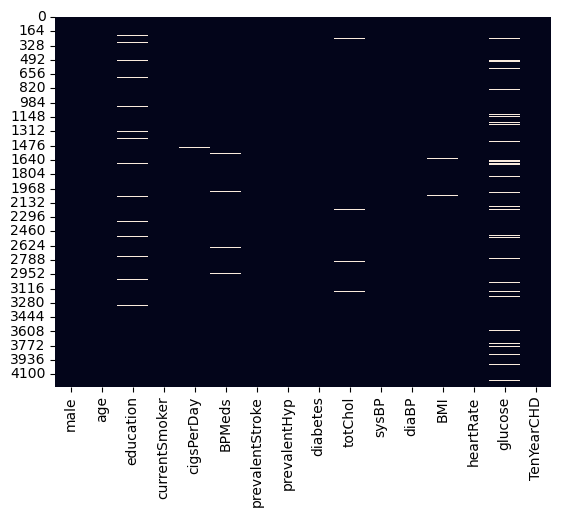

In [13]:
sns.heatmap(df.isnull(), cbar=False)
plt.show()

<h3>Handling Missing Values</h3>

Handling education col

In [14]:
df['education']=df['education'].fillna(df['education'].mode()[0])
df['education'].isnull().sum()

np.int64(0)

Handling cigperday

In [15]:
df["cigsPerDay"]=df["cigsPerDay"].fillna(df["cigsPerDay"].median())
df["cigsPerDay"].isnull().sum()

np.int64(0)

Handling heart rate

In [16]:
df['heartRate']=df['heartRate'].fillna(df["heartRate"].median())
df['heartRate'].isnull().sum()

np.int64(0)

Handling BPMeds colums

In [17]:
df['BPMeds'].fillna(df['BPMeds'].mode()[0], inplace=True)


/tmp/ipykernel_4279/224518942.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['BPMeds'].fillna(df['BPMeds'].mode()[0], inplace=True)


In [18]:
df['BPMeds'].isnull().sum()

np.int64(0)

Handling BMI 

In [19]:
df['BMI'] = df["BMI"].fillna(df["BMI"].median())

In [20]:
df['BMI'].isnull().sum()

np.int64(0)

Handling totchol

In [21]:
df['totChol']=df['totChol'].fillna(df['totChol'].median())

In [22]:
df['totChol'].isnull().sum()

np.int64(0)

Handling glucose column

In [23]:
df["glucose"]=df["glucose"].fillna(df["glucose"].median())

In [24]:
df['glucose'].isnull().sum()

np.int64(0)

In [25]:
df.isnull().sum()

male               0
age                0
education          0
currentSmoker      0
cigsPerDay         0
BPMeds             0
prevalentStroke    0
prevalentHyp       0
diabetes           0
totChol            0
sysBP              0
diaBP              0
BMI                0
heartRate          0
glucose            0
TenYearCHD         0
dtype: int64

<h3>Handling Outliers</h3>

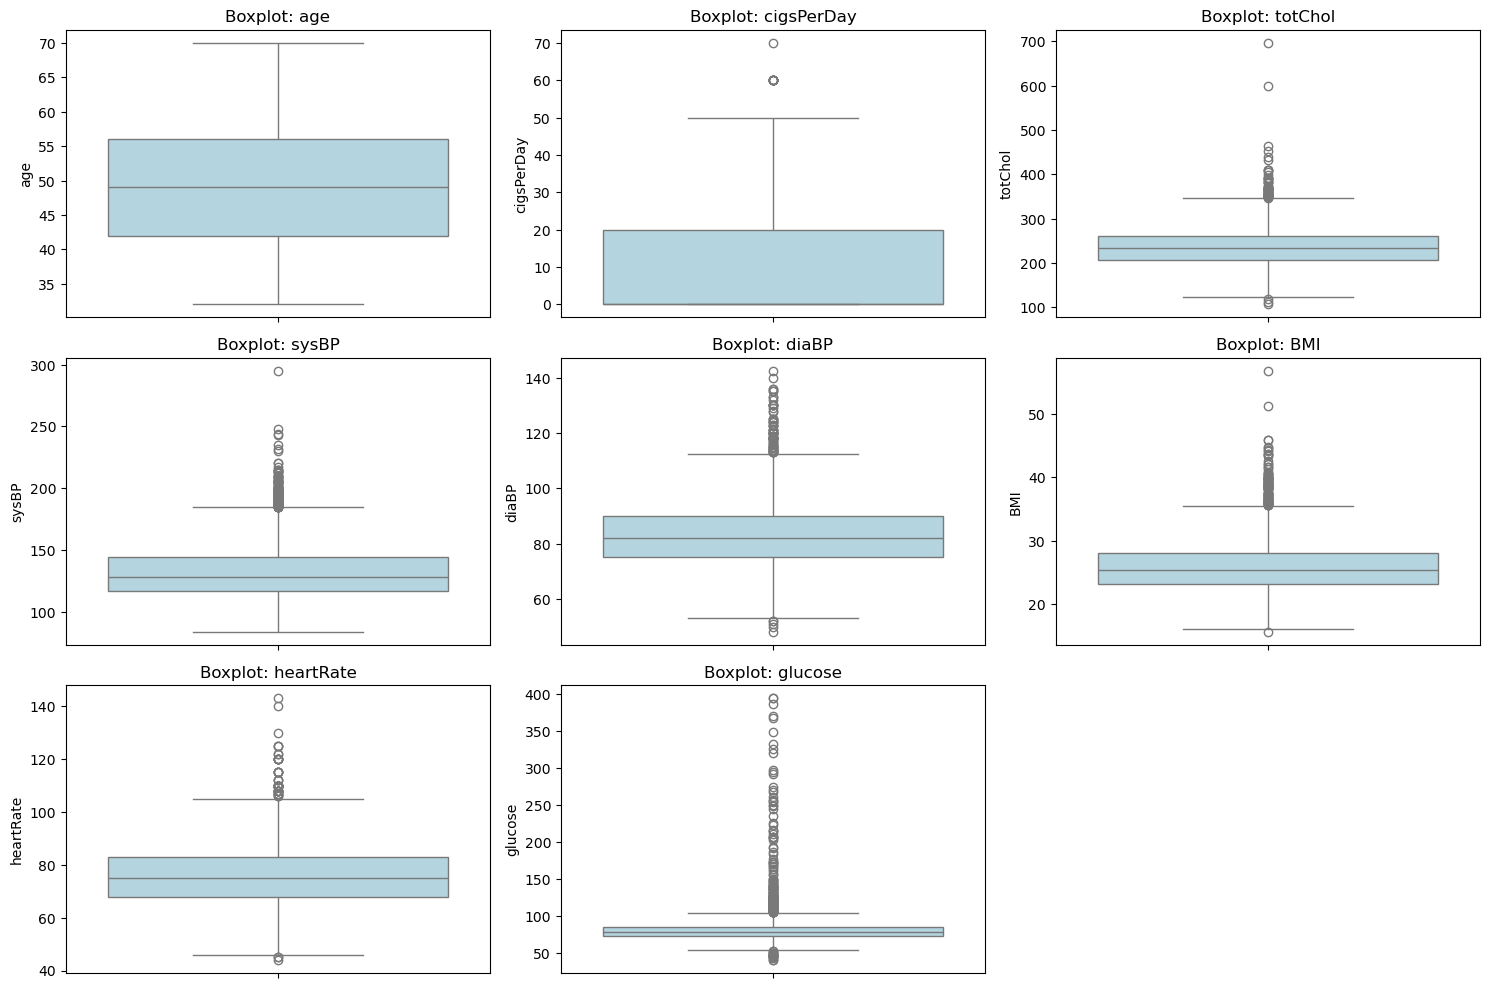

In [26]:
num_cols = ['age', 'cigsPerDay', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose']

plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(y=df[col], color='lightblue')
    plt.title(f'Boxplot: {col}')
plt.tight_layout()
plt.show()

- conclusion : outliers are present in these 'cigsPerDay', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose' columns

In [27]:
df.min()

male                 0.00
age                 32.00
education            1.00
currentSmoker        0.00
cigsPerDay           0.00
BPMeds               0.00
prevalentStroke      0.00
prevalentHyp         0.00
diabetes             0.00
totChol            107.00
sysBP               83.50
diaBP               48.00
BMI                 15.54
heartRate           44.00
glucose             40.00
TenYearCHD           0.00
dtype: float64

In [28]:
df.max()

male                 1.0
age                 70.0
education            4.0
currentSmoker        1.0
cigsPerDay          70.0
BPMeds               1.0
prevalentStroke      1.0
prevalentHyp         1.0
diabetes             1.0
totChol            696.0
sysBP              295.0
diaBP              142.5
BMI                 56.8
heartRate          143.0
glucose            394.0
TenYearCHD           1.0
dtype: float64

filling cigsPerDay

In [29]:
df.loc[(df['cigsPerDay']>50),"cigsPerDay"]=50
df[ (df['cigsPerDay']>50)].shape[0]

0

In [30]:
print('Number of rows to be deleted for outliers removal is ',
      len(df[df['sysBP'] > 220]) + 
      len(df[df['BMI'] > 50]) + 
      len(df[df['heartRate'] > 125]) +
     len(df[df['glucose'] > 200]) + 
     len(df[df['totChol'] > 450])+
     len(df[df['diaBP']>140]))

Number of rows to be deleted for outliers removal is  51


So we drop the rows

In [31]:

df = df[df['sysBP'] < 220]
df = df[df['BMI'] < 50]
df = df[df['heartRate'] < 125]
df = df[df['glucose'] < 200]
df = df[df['totChol'] < 450]

In [32]:
df.min()

male                 0.00
age                 32.00
education            1.00
currentSmoker        0.00
cigsPerDay           0.00
BPMeds               0.00
prevalentStroke      0.00
prevalentHyp         0.00
diabetes             0.00
totChol            107.00
sysBP               83.50
diaBP               48.00
BMI                 15.54
heartRate           44.00
glucose             40.00
TenYearCHD           0.00
dtype: float64

In [33]:
df.max()

male                 1.0
age                 70.0
education            4.0
currentSmoker        1.0
cigsPerDay          50.0
BPMeds               1.0
prevalentStroke      1.0
prevalentHyp         1.0
diabetes             1.0
totChol            439.0
sysBP              217.0
diaBP              140.0
BMI                 45.8
heartRate          122.0
glucose            193.0
TenYearCHD           1.0
dtype: float64

In [34]:
df.nunique()

male                  2
age                  39
education             4
currentSmoker         2
cigsPerDay           31
BPMeds                2
prevalentStroke       2
prevalentHyp          2
diabetes              2
totChol             244
sysBP               224
diaBP               144
BMI                1346
heartRate            69
glucose             112
TenYearCHD            2
dtype: int64

<h4>Feature Engineering</h4>

In [35]:
df['pulse_pressure']    = df['sysBP'] - df['diaBP']        
df['smoking_intensity'] = df['currentSmoker'] * df['cigsPerDay'] 
df['age_bp']            = df['age'] * df['sysBP']            
df['chol_age']          = df['totChol'] * df['age']          
df['bmi_age']           = df['BMI'] * df['age']              
df['glucose_bp']        = df['glucose'] * df['sysBP']        

df['age_group'] = pd.cut(df['age'], bins=[30,40,50,60,70], labels=[0,1,2,3]).astype(float)
df['age_group'] = df['age_group'].fillna(0)

print('New features:')
new_feats = ['pulse_pressure','smoking_intensity','age_bp','chol_age','bmi_age','glucose_bp','age_group']
df[new_feats].describe()

New features:


,pulse_pressure,smoking_intensity,age_bp,chol_age,bmi_age,glucose_bp,age_group
count,4186.000000,4186.000000,4186.000000,4186.000000,4186.000000,4186.000000,4186.000000
mean,49.168896,8.957000,6604.063784,11797.425466,1280.174171,10589.547898,1.397038
std,14.174831,11.802398,1875.373070,3321.194267,317.725123,2738.395882,0.929809
min,15.000000,0.000000,2922.500000,4294.000000,584.850000,4590.000000,0.000000
25%,39.625000,0.000000,5160.000000,9276.250000,1035.872500,8814.000000,1.000000
50%,46.500000,0.000000,6272.000000,11500.000000,1249.665000,10063.000000,1.000000
75%,55.500000,20.000000,7733.250000,13979.500000,1481.872500,11774.000000,2.000000
max,130.000000,50.000000,14405.000000,24857.000000,2954.030000,33775.000000,3.000000


<h3>Target Column Analaysis</h3>

In [36]:
X = df.drop('TenYearCHD', axis=1)   # all columns except target
y = df['TenYearCHD']

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nFeatures included:", X.columns.tolist())

X shape: (4186, 22)
y shape: (4186,)

Features included: ['male', 'age', 'education', 'currentSmoker', 'cigsPerDay', 'BPMeds', 'prevalentStroke', 'prevalentHyp', 'diabetes', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose', 'pulse_pressure', 'smoking_intensity', 'age_bp', 'chol_age', 'bmi_age', 'glucose_bp', 'age_group']


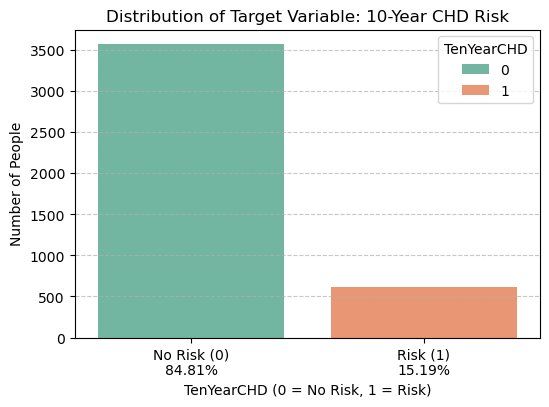

In [37]:
#Using bar chart
plt.figure(figsize=(6, 4))
sns.countplot(x='TenYearCHD', data=df,hue='TenYearCHD', palette=['#66c2a5', '#fc8d62'])
plt.title('Distribution of Target Variable: 10-Year CHD Risk')
plt.xlabel('TenYearCHD (0 = No Risk, 1 = Risk)')
plt.ylabel('Number of People')
plt.xticks([0, 1], ['No Risk (0)\n84.81%', 'Risk (1)\n15.19%'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

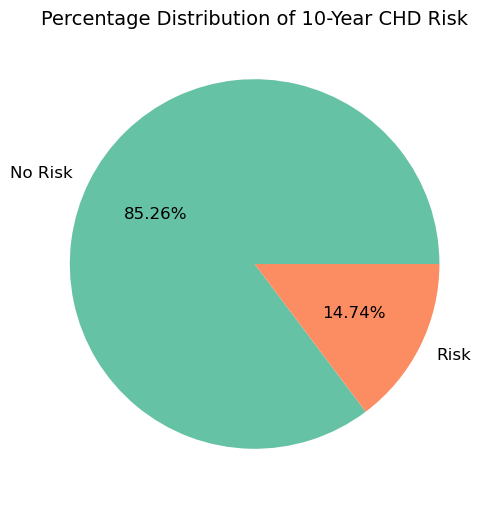

In [38]:
#using PIE CHART
plt.figure(figsize=(6, 6))
df['TenYearCHD'].value_counts().plot(kind='pie', autopct='%1.2f%%',colors=['#66c2a5', '#fc8d62'],
                                     labels=['No Risk', 'Risk'],textprops={'fontsize': 12})
plt.title('Percentage Distribution of 10-Year CHD Risk', fontsize=14)
plt.ylabel('')
plt.show()

- conclusion :
    It is imbalenced so we need to balance

<h4> Class Imbalance Handling — Oversampling (Manual SMOTE)</h4>

In [39]:
print('Before balancing:', df['TenYearCHD'].value_counts().to_dict())

df_majority = df[df['TenYearCHD'] == 0]
df_minority = df[df['TenYearCHD'] == 1]

n_target = int(len(df_majority) * 0.50)
df_minority_up = resample(df_minority, replace=True, n_samples=n_target, random_state=42)


df_balanced = pd.concat([df_majority, df_minority_up])
df_balanced  = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print('After balancing :', df_balanced['TenYearCHD'].value_counts().to_dict())
print(f'Balanced shape  : {df_balanced.shape}')

Before balancing: {0: 3569, 1: 617}
After balancing : {0: 3569, 1: 1784}
Balanced shape  : (5353, 23)


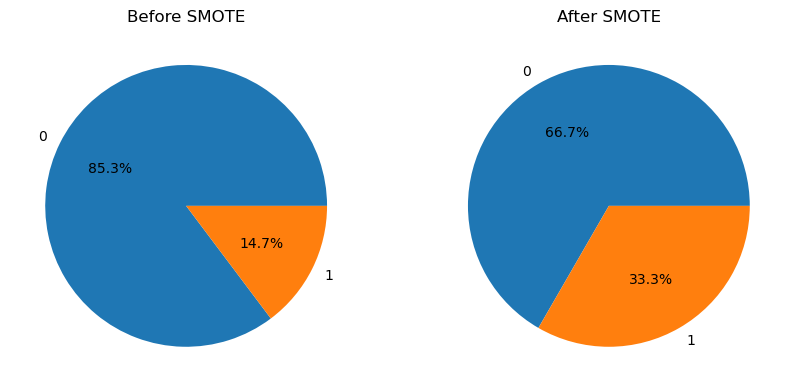

In [40]:
before=df['TenYearCHD'].value_counts(normalize=True).mul(100).round(2)

after=df_balanced['TenYearCHD'].value_counts(normalize=True).mul(100).round(2)
plt.figure(figsize=(10,5))

# Before
plt.subplot(1,2,1)
plt.pie(before, labels=['0','1'], autopct='%1.1f%%')
plt.title("Before SMOTE")

# After
plt.subplot(1,2,2)
plt.pie(after, labels=['0','1'], autopct='%1.1f%%')
plt.title("After SMOTE")

plt.show()

<h4>Train Test Split</h4>

In [41]:
X = df_balanced.drop('TenYearCHD', axis=1)
y = df_balanced['TenYearCHD']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)


print(f'Train samples : {X_train.shape[0]}')
print(f'Test  samples : {X_test.shape[0]}')
print(f'Features      : {X_train.shape[1]}')

Train samples : 4282
Test  samples : 1071
Features      : 22


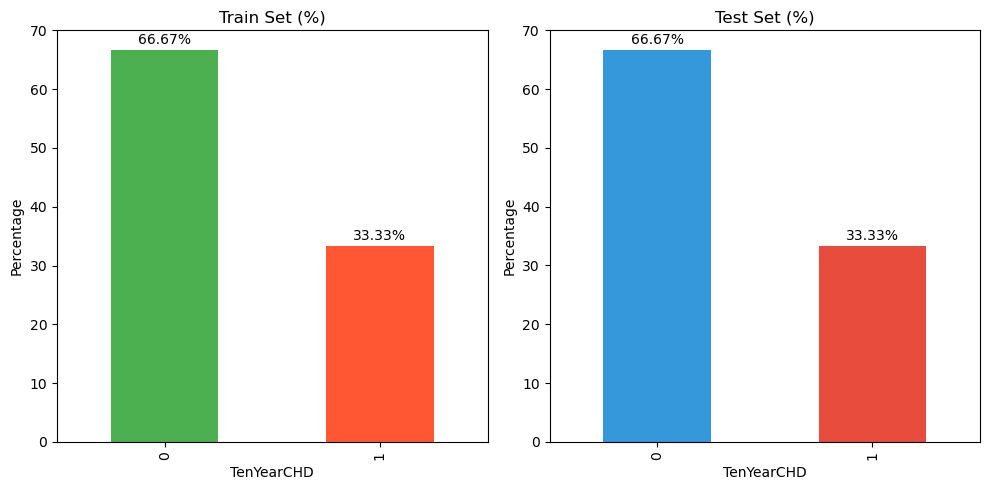

In [42]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
train_pct = y_train.value_counts(normalize=True).mul(100)
colors1 = ['#4CAF50', '#FF5733']
ax1 = train_pct.plot(kind='bar', color=colors1)
plt.title("Train Set (%)")
plt.ylabel("Percentage")
for i, v in enumerate(train_pct):
    ax1.text(i, v + 1, f"{v:.2f}%", ha='center')

# Test
plt.subplot(1,2,2)
test_pct = y_test.value_counts(normalize=True).mul(100)
colors2 = ['#3498DB', '#E74C3C']
ax2 = test_pct.plot(kind='bar', color=colors2)
plt.title("Test Set (%)")
plt.ylabel("Percentage")

for i, v in enumerate(test_pct):
    ax2.text(i, v + 1, f"{v:.2f}%", ha='center')

plt.tight_layout()
plt.show()

<h4>Scaling</h4>

In [43]:
scaler = StandardScaler()
X_train_sc = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_sc  = pd.DataFrame(scaler.transform(X_test),     columns=X_test.columns)
print('Scaling complete.')
X_train_sc.head()

Scaling complete.


,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,...,BMI,heartRate,glucose,pulse_pressure,smoking_intensity,age_bp,chol_age,bmi_age,glucose_bp,age_group
0,1.067174,-1.333066,1.999173,0.990702,0.457852,-0.179735,-0.088128,-0.733536,-0.14401,-0.691225,...,-1.302098,-0.479781,-0.176311,0.306210,0.457852,-0.819536,-1.204930,-1.561891,-0.108780,-1.614550
1,1.067174,-1.218134,1.032108,0.990702,0.457852,-0.179735,-0.088128,-0.733536,-0.14401,-0.806134,...,-0.304210,-0.060220,-0.176311,-0.642553,0.457852,-0.997195,-1.202532,-1.005983,-0.432496,-1.614550
2,1.067174,-1.677861,1.032108,-1.009385,-0.776527,-0.179735,-0.088128,-0.733536,-0.14401,-1.334716,...,0.448540,-0.395869,-0.044382,-0.845859,-0.776527,-1.473009,-1.694212,-0.973957,-0.679433,-1.614550
3,1.067174,-1.103203,-0.902022,0.990702,0.869312,-0.179735,-0.088128,1.363260,-0.14401,0.503828,...,1.760899,1.618024,0.681226,1.051666,0.869312,-0.342692,-0.441027,0.114573,1.001744,-0.544845
4,-0.937054,-0.068819,0.065043,0.990702,0.869312,-0.179735,-0.088128,-0.733536,-0.14401,-0.829116,...,-0.232401,2.876708,1.142976,1.051666,0.869312,0.022409,-0.608918,-0.205630,0.926695,-0.544845


In [44]:
print(f'Mean of scaled training features (should be ~0):')
print(X_train_sc.mean().round(4).head(5))
print(f'Std of scaled training features (should be ~1):')
print(X_train_sc.std().round(4).head(5))

Mean of scaled training features (should be ~0):
male             0.0
age             -0.0
education       -0.0
currentSmoker    0.0
cigsPerDay      -0.0
dtype: float64
Std of scaled training features (should be ~1):
male             1.0001
age              1.0001
education        1.0001
currentSmoker    1.0001
cigsPerDay       1.0001
dtype: float64


<h4>Saving Preprocessed data</h4>

In [45]:
train_out = X_train_sc.copy()
train_out['TenYearCHD'] = y_train.values
train_out['_split']     = 'train'

test_out  = X_test_sc.copy()
test_out['TenYearCHD'] = y_test.values
test_out['_split']     = 'test'

preprocessed = pd.concat([train_out, test_out], ignore_index=True)
preprocessed.to_csv('preprocessed_data.csv', index=False)

print(f'Saved  →  preprocessed_data.csv')
print(f'Shape     : {preprocessed.shape}')
print(f'Train rows: {(preprocessed["_split"]=="train").sum()}')
print(f'Test  rows: {(preprocessed["_split"]=="test").sum()}')
preprocessed.head(3)

Saved  →  preprocessed_data.csv
Shape     : (5353, 24)
Train rows: 4282
Test  rows: 1071


,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,...,glucose,pulse_pressure,smoking_intensity,age_bp,chol_age,bmi_age,glucose_bp,age_group,TenYearCHD,_split
0,1.067174,-1.333066,1.999173,0.990702,0.457852,-0.179735,-0.088128,-0.733536,-0.14401,-0.691225,...,-0.176311,0.306210,0.457852,-0.819536,-1.204930,-1.561891,-0.108780,-1.61455,0,train
1,1.067174,-1.218134,1.032108,0.990702,0.457852,-0.179735,-0.088128,-0.733536,-0.14401,-0.806134,...,-0.176311,-0.642553,0.457852,-0.997195,-1.202532,-1.005983,-0.432496,-1.61455,0,train
2,1.067174,-1.677861,1.032108,-1.009385,-0.776527,-0.179735,-0.088128,-0.733536,-0.14401,-1.334716,...,-0.044382,-0.845859,-0.776527,-1.473009,-1.694212,-0.973957,-0.679433,-1.61455,0,train


<h4>Preprocessing Summary</h4>

In [46]:
print('='*50)
print('       PREPROCESSING COMPLETE — SUMMARY')
print('='*50)
print(f'  Original rows - cols   : {4240} - 16')
print(f'  After feature eng.     : {df_balanced.shape[1]-1} features')
print(f'  Balanced dataset rows  : {df_balanced.shape[0]}')
print(f'  Train - Test split     : 80% - 20%')
print(f'  Scaling                : StandardScaler')
print('='*52)

       PREPROCESSING COMPLETE — SUMMARY
  Original rows - cols   : 4240 - 16
  After feature eng.     : 22 features
  Balanced dataset rows  : 5353
  Train - Test split     : 80% - 20%
  Scaling                : StandardScaler
